# Create Heart Well

Parse the well data from the `ALDIS2.MAC`.

In [1]:
var_map = {
"DG0":0x70+0x80,
"DG225":0x67+0x80,
"DG450":0x4F+0x80,
"DG675":0x2A+0x80,
"DG900":0x00+0x80,
"DI0":0x0F0,
"DI1":0x0B8,
"DI2":0x80,
"DI3":0x48,
"DI4":0x10,
"CR0":0x70+0x80,
"CR1":0x70+0x80,
"CR2":0x38+0x80,
"CR3":0x38+0x80,
"CR4":0x0+0x80,
"PX0":0x6C+0x80,
"PX1":0x55+0x80,
"PX2":0x31+0x80,
"PX3":0x10+0x80,
"PZ0":0x14+0x80,
"PZ1":0x30+0x80,
"PZ2":0x38+0x80,
"PZ3":0x27+0x80,
"-DG0":0xFF-(0x70+0x80),
"-DG225":0xFF-(0x67+0x80),
"-DG450":0xFF-(0x4F+0x80),
"-DG675":0xFF-(0x2A+0x80),
"-DG900":0xFF-(0x00+0x80),
"-DI0":0xFF-0x0F0,
"-DI1":0xFF-0x0B8,
"-DI2":0xFF-0x80,
"-DI3":0xFF-0x48,
"-DI4":0xFF-0x10,
"-CR0":0xFF-(0x70+0x80),
"-CR1":0xFF-(0x70+0x80),
"-CR2":0xFF-(0x38+0x80),
"-CR3":0xFF-(0x38+0x80),
"-CR4":0xFF-(0x0+0x80),
"-PX0":0xFF-(0x6C+0x80),
"-PX1":0xFF-(0x55+0x80),
"-PX2":0xFF-(0x31+0x80),
"-PX3":0xFF-(0x10+0x80),
"-PZ0":0xFF-(0x14+0x80),
"-PZ1":0xFF-(0x30+0x80),
"-PZ2":0xFF-(0x38+0x80),
"-PZ3":0xFF-(0x27+0x80),
}

In [4]:
x_data = """
  .BYTE 0DA,0A4,87,80,79,5C,26,10  ;HEART
  .BYTE 10,20,48,80,0B8,0E0,0F0,0F0

"""
y_data = """
  .BYTE 0E4,0E8,0B7,80,0B7,0E8,0E4,0B2  ;HEART
  .BYTE 7A,47,20,10,20,47,7A,0B2
    
"""
"""
HOLRAP:	
    .BYTE 0
"""
# tells us whether the well is open or closed.
closed = [0]

A function for parsing the well data.

In [5]:
def parse_vector_data(data):
    arrays = []
    vals = []
    for l in data.splitlines()[1:]:
        if not l.strip():
            arrays += [(nm,vals)]
            vals = []
            continue
        if ';' in l:
            nm = l.split(';')[1].strip()
        dt = [x for x in l.split(' ') if x][1]
        ls = [var_map[x] if x in var_map else int(x,16) for x in dt.split(',')]
        vals += ls
    return arrays


## Create 2D Visual

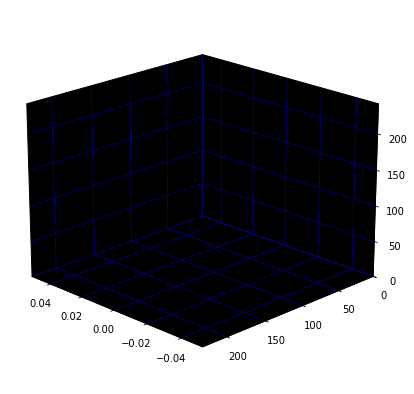

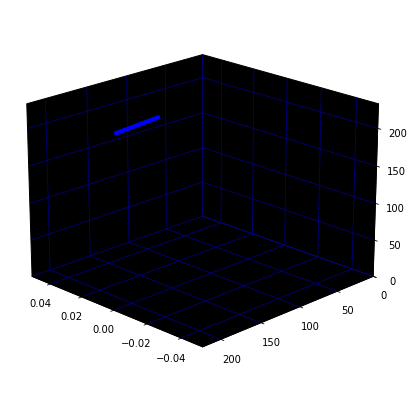

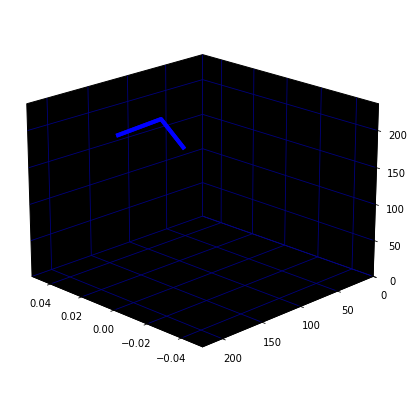

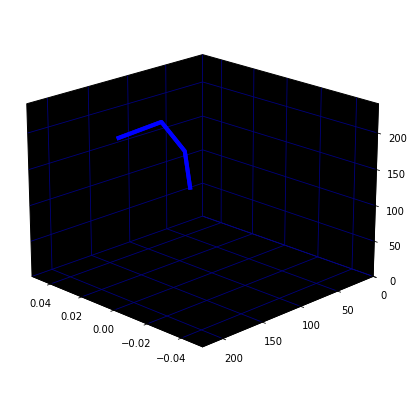

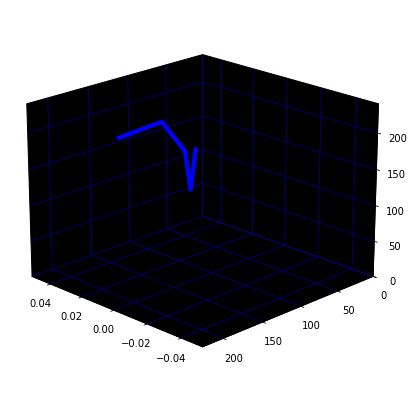

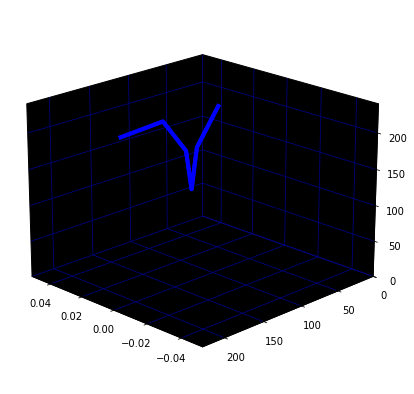

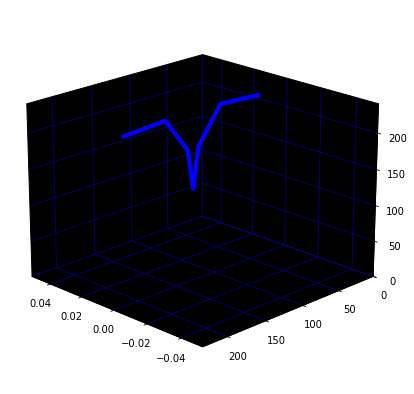

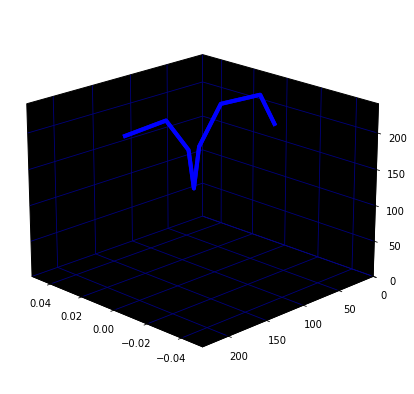

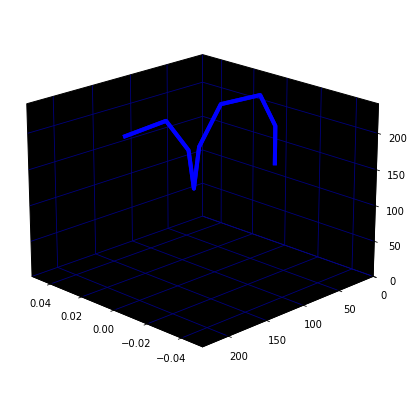

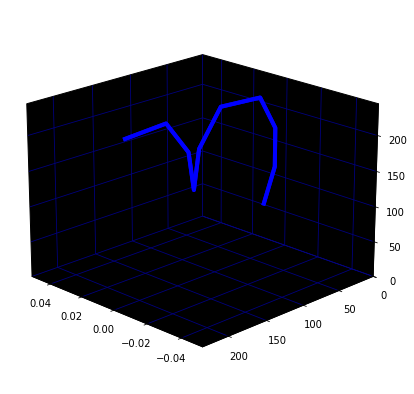

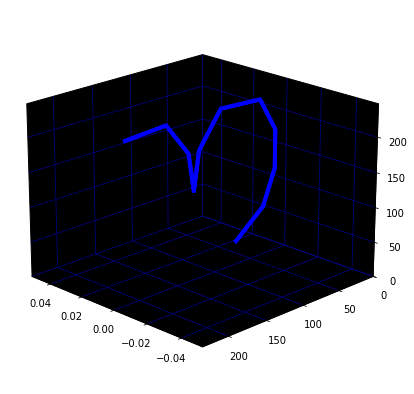

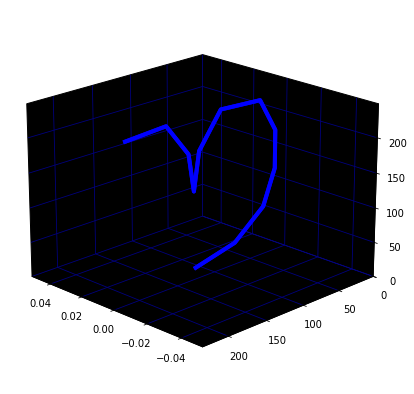

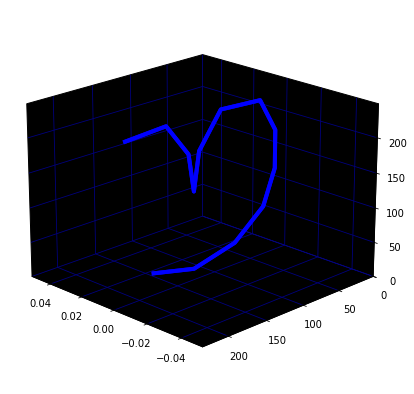

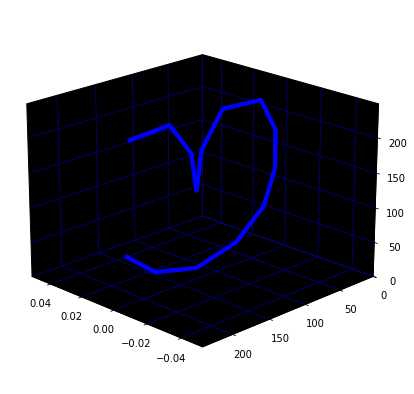

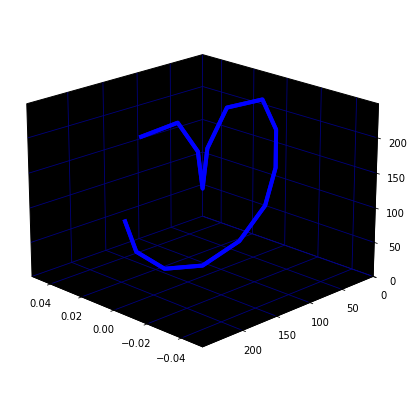

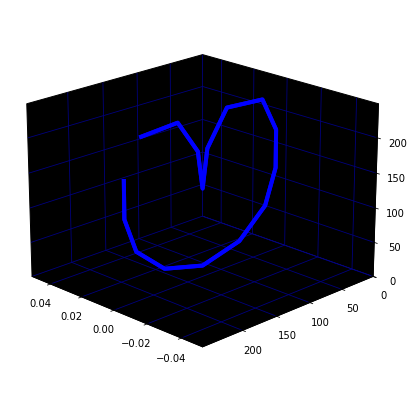

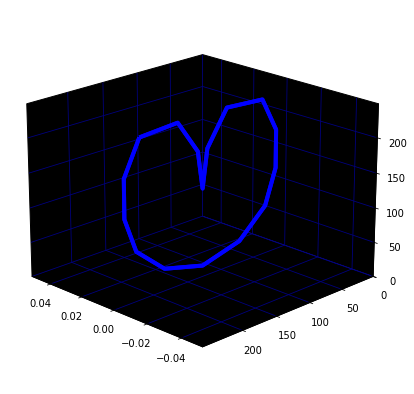

In [36]:
from matplotlib import pyplot as plt
from well_graphs import create3DVertices,makeFullGraph,create2DVertices

def makeGradualGraph(x, y, z, filename, titlename=""):
    #Change the Size of Graph using Figsize
    fig = plt.figure(figsize=(7,7))
    ax = plt.axes(projection='3d')
    plt.rcParams['grid.color'] = "navy"
    ax.plot_wireframe(x, y, z, color ='blue',linewidth=4)
    ax.view_init(azim=135,elev=20,vertical_axis="y")
    ax.xaxis.set_pane_color("black")
    ax.yaxis.set_pane_color("black")
    ax.zaxis.set_pane_color("black")
    ax.set_yticks(range(0,250,50))
    ax.set_xticks(range(0,250,50))
    if titlename:
        plt.title(titlename,y=1,fontsize = 30)
    plt.savefig(filename, transparent=True,bbox_inches='tight')
    return

x_vecs = parse_vector_data(x_data)
y_vecs = parse_vector_data(y_data)
x_vectors = x_vecs[0]
y_vectors = y_vecs[0]
xnm,xs = x_vectors
ynm,ys = y_vectors
planar = -1

for i in range(1,len(xs)+1):
    vertices = list(zip(xs[:i],ys[:i]))
    x,y,z = create2DVertices(vertices,planar)
    makeGradualGraph(x,y,z, f"heart_graphs/{xnm}_{i}_2d.png")

planar = 0
vertices = list(zip(xs,ys))
x,y,z = create2DVertices(vertices,planar)
makeGradualGraph(x,y,z, f"heart_graphs/{xnm}_17_2d.png")


In [62]:
"""
Draw vector to (-3,-1)    & \icode{0x5FDD}          & \icode{01011111 11011101} \\
                         &                          & \icode{   5   F    D   D} \\
"""
px,py = 0,0
for i in range(1,len(vertices)):
    x,y  = vertices[i]
    nx,ny = x-px,y-py
    b1 = 0x40 | (0x1F & ny)
    b2 = 0xC0 | (0x1F & nx)
    h1 = hex(b1).upper()[2:]
    h2 = hex(b2).upper()[2:]
    bits1 = format(int(h1,16), '#010b')[2:]
    bits2 = format(int(h2,16), '#010b')[2:]
    print(f"""
Draw vector to ({nx},{ny})  & \\icode{{0x{h1+h2}}}   & \icode{{{bits1} {bits2}}} \\\\
                         &         & \icode{{   {h1[0]}   {h1[1]}    {h2[0]}   {h2[1]}}} \\\\
"""
    )
    px,py = vertices[i-1]



Draw vector to (164,232)  & \icode{0x48C4}   & \icode{01001000 11000100} \\
                         &         & \icode{   4   8    C   4} \\


Draw vector to (-83,-45)  & \icode{0x53CD}   & \icode{01010011 11001101} \\
                         &         & \icode{   5   3    C   D} \\


Draw vector to (-36,-104)  & \icode{0x58DC}   & \icode{01011000 11011100} \\
                         &         & \icode{   5   8    D   C} \\


Draw vector to (-14,0)  & \icode{0x40D2}   & \icode{01000000 11010010} \\
                         &         & \icode{   4   0    D   2} \\


Draw vector to (-36,104)  & \icode{0x48DC}   & \icode{01001000 11011100} \\
                         &         & \icode{   4   8    D   C} \\


Draw vector to (-83,45)  & \icode{0x4DCD}   & \icode{01001101 11001101} \\
                         &         & \icode{   4   D    C   D} \\


Draw vector to (-76,-54)  & \icode{0x4AD4}   & \icode{01001010 11010100} \\
                         &         & \icode{   4   A    D   4